<a href="https://colab.research.google.com/github/asheldrick-research/ecsm-framework/blob/main/ECSM_Magic_Numbers_Response_Closure_V2_Regime_Aware_Robustness.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ECSM Magic Numbers Response Closure V2 — Regime-Aware Robustness Test

This notebook extends V1 by treating the raw AME2020 shell-gap signal as the baseline and then testing whether the magic-number response-closure signal survives sensible robustness cuts.

**Aim.** Test whether the standard magic numbers

\[
2,\;8,\;20,\;28,\;50,\;82,\;126
\]

appear as enhanced finite-response closure discontinuities in nuclear separation-energy data.

**V2 additions.**

- removes ultra-light outliers in controlled variants;
- separates neutron and proton channels;
- evaluates all-data and cleaned samples side by side;
- reports light, medium, heavy, and full-regime statistics;
- ranks shell-gap peaks and checks how many known magic numbers are recovered;
- exports paper-ready figures, tables, ZIP files, and a verdict JSON.

Expected input: `/content/drive/MyDrive/ame2020.csv`.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# CELL 01 — SETUP

import json, math, zipfile, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)

OUT = Path("ecsm_magic_numbers_response_closure_v2_out")
FIG = OUT / "figures"
TAB = OUT / "tables"
DATA = OUT / "data"
for p in [OUT, FIG, TAB, DATA]:
    p.mkdir(parents=True, exist_ok=True)

AME_CSV = Path("/content/drive/MyDrive/ame2020.csv")
MAGIC = np.array([2, 8, 20, 28, 50, 82, 126], dtype=int)
MAGIC_N = MAGIC.copy()
MAGIC_Z = np.array([2, 8, 20, 28, 50, 82], dtype=int)  # Z=126 not present in AME2020

plt.rcParams.update({"figure.dpi": 120})
print("Output directory:", OUT)
print("Expected AME2020 CSV:", AME_CSV)

Output directory: ecsm_magic_numbers_response_closure_v2_out
Expected AME2020 CSV: /content/drive/MyDrive/ame2020.csv


## Load AME2020 CSV

The CSV is expected to have the columns used previously: `nucid`, `n`, `z`, and `binding`. In the AME2020 CSV used here, `binding` is binding energy per nucleon in keV, so we convert to MeV per nucleon and total binding energy.

In [3]:
# CELL 02 — LOAD AND STANDARDISE AME2020

if not AME_CSV.exists():
    raise FileNotFoundError(
        f"Missing {AME_CSV}. Upload ame2020.csv to Google Drive or edit AME_CSV in Cell 01."
    )

raw = pd.read_csv(AME_CSV)
print("Loaded:", AME_CSV)
print("Shape:", raw.shape)
print("First columns:", list(raw.columns[:20]))
display(raw.head())

required = {"nucid", "n", "z", "binding"}
missing = required - set(raw.columns)
if missing:
    raise KeyError(f"AME CSV missing required columns: {sorted(missing)}")

work = raw.copy()
work["N"] = pd.to_numeric(work["n"], errors="coerce").astype("Int64")
work["Z"] = pd.to_numeric(work["z"], errors="coerce").astype("Int64")
work["A"] = (work["N"] + work["Z"]).astype("Int64")
work["BE_per_A_MeV"] = pd.to_numeric(work["binding"], errors="coerce") / 1000.0
work["BE_total_MeV"] = work["BE_per_A_MeV"] * work["A"].astype(float)
work = work[np.isfinite(work["BE_per_A_MeV"]) & np.isfinite(work["BE_total_MeV"])]
work = work[work["A"] >= 1].copy()
work[["A", "N", "Z"]] = work[["A", "N", "Z"]].astype(int)
work = work.sort_values(["A", "Z", "N", "nucid"]).reset_index(drop=True)

summary = {
    "data_source": str(AME_CSV),
    "n_rows": int(len(work)),
    "A_min": int(work.A.min()),
    "A_max": int(work.A.max()),
    "Z_min": int(work.Z.min()),
    "Z_max": int(work.Z.max()),
    "N_min": int(work.N.min()),
    "N_max": int(work.N.max()),
    "BEA_min_MeV": float(work.BE_per_A_MeV.min()),
    "BEA_max_MeV": float(work.BE_per_A_MeV.max()),
}
print(json.dumps(summary, indent=2))
with open(OUT / "dataset_summary_v2.json", "w") as f:
    json.dump(summary, f, indent=2)

display(work[["nucid", "A", "Z", "N", "BE_per_A_MeV", "BE_total_MeV"]].head(15))

Loaded: /content/drive/MyDrive/ame2020.csv
Shape: (3378, 104)
First columns: ['nucid', 'n', 'z', 'mass_excess', 'mass_excess_num', 'mass_excess_unc', 'mass_excess_sys', 'mass_excess_round', 'mass_excess_round_unc', 'binding', 'binding_num', 'binding_unc', 'binding_sys', 'binding_round', 'binding_round_unc', 'beta_decay_en_round', 'beta_decay_en_round_unc', 'beta_decay_en', 'beta_decay_en_num', 'beta_decay_en_unc']


,nucid,n,z,mass_excess,mass_excess_num,mass_excess_unc,mass_excess_sys,mass_excess_round,mass_excess_round_unc,binding,...,qna_num,qna_unc,qna_round,qna_round_unc,qna_sys,qec_num,qec_unc,qec_round,qec_round_unc,qec
0,1N,1,0,8071.318060,8071.318060,0.000440,N,8071.31810,0.00040,0.00000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1H,0,1,7288.971064,7288.971064,0.000013,N,7288.97106,0.00001,0.00000,...,NaN,NaN,NaN,NaN,NaN,-782.347,0.0,-782.347,0.0,-782.347
2,2H,1,1,13135.722895,13135.722895,0.000015,N,13135.72290,0.00002,1112.28310,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3H,2,1,14949.810900,14949.810900,0.000080,N,14949.81090,0.00008,2827.26540,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,3HE,1,2,14931.218880,14931.218880,0.000060,N,14931.21888,0.00006,2572.68044,...,NaN,NaN,20577.6189,0.0005,NaN,-18.592,0.0,-18.592,0.0,-18.592


{
  "data_source": "/content/drive/MyDrive/ame2020.csv",
  "n_rows": 3378,
  "A_min": 1,
  "A_max": 295,
  "Z_min": 0,
  "Z_max": 118,
  "N_min": 0,
  "N_max": 177,
  "BEA_min_MeV": -2.267,
  "BEA_max_MeV": 8.7945555
}


,nucid,A,Z,N,BE_per_A_MeV,BE_total_MeV
0,1N,1,0,1,0.000000,0.000000
1,1H,1,1,0,0.000000,0.000000
2,2H,2,1,1,1.112283,2.224566
3,3H,3,1,2,2.827265,8.481796
4,3HE,3,2,1,2.572680,7.718041
5,3LI,3,3,0,-2.267000,-6.801000
6,4H,4,1,3,1.720449,6.881796
7,4HE,4,2,2,7.073916,28.295662
8,4LI,4,3,1,1.153760,4.615041
9,5H,5,1,4,1.336359,6.681796


## Compute separation energies and two-particle shell gaps

For a nuclide \((N,Z)\), the total binding energy is \(B(N,Z)\). We compute

\[
S_n(N,Z) = B(N,Z)-B(N-1,Z),
\]

\[
S_{2n}(N,Z) = B(N,Z)-B(N-2,Z),
\]

and analogously for proton separation energies. The two-particle shell-gap discontinuity is estimated as

\[
\delta_{2n}(N,Z) = S_{2n}(N,Z)-S_{2n}(N+2,Z),
\]

\[
\delta_{2p}(N,Z) = S_{2p}(N,Z)-S_{2p}(N,Z+2).
\]

Large positive values indicate a strong closure discontinuity.

In [4]:
# CELL 03 — SEPARATION ENERGIES AND SHELL-GAP DISCONTINUITIES

B = {(int(r.N), int(r.Z)): float(r.BE_total_MeV) for r in work.itertuples()}

def getB(N, Z):
    return B.get((int(N), int(Z)), np.nan)

Sn=[]; S2n=[]; Sp=[]; S2p=[]
for r in work.itertuples():
    N, Z, Bt = int(r.N), int(r.Z), float(r.BE_total_MeV)
    Sn.append(Bt - getB(N-1, Z))
    S2n.append(Bt - getB(N-2, Z))
    Sp.append(Bt - getB(N, Z-1))
    S2p.append(Bt - getB(N, Z-2))
work["Sn_MeV"] = Sn
work["S2n_MeV"] = S2n
work["Sp_MeV"] = Sp
work["S2p_MeV"] = S2p

# shell-gap discontinuity at closure N or Z: S2 at closure minus S2 after adding two particles
work["delta2n_MeV"] = [s2 - (getB(int(r.N)+2, int(r.Z)) - getB(int(r.N), int(r.Z))) for s2, r in zip(work["S2n_MeV"], work.itertuples())]
work["delta2p_MeV"] = [s2 - (getB(int(r.N), int(r.Z)+2) - getB(int(r.N), int(r.Z))) for s2, r in zip(work["S2p_MeV"], work.itertuples())]

work["is_magic_N"] = work["N"].isin(MAGIC_N)
work["is_magic_Z"] = work["Z"].isin(MAGIC_Z)
work["is_even_even"] = (work["N"] % 2 == 0) & (work["Z"] % 2 == 0)
work["is_odd_odd"] = (work["N"] % 2 == 1) & (work["Z"] % 2 == 1)

# Regime labels for robustness analysis.
work["A_regime"] = pd.cut(
    work["A"], bins=[0, 8, 20, 56, 120, 10000],
    labels=["ultralight_A<=8", "light_9_20", "medium_21_56", "heavy_57_120", "very_heavy_>120"]
)

work.to_csv(TAB / "ame2020_with_separation_and_shell_gaps_v2.csv", index=False)
print("Saved:", TAB / "ame2020_with_separation_and_shell_gaps_v2.csv")
display(work[["nucid", "A", "Z", "N", "BE_per_A_MeV", "Sn_MeV", "S2n_MeV", "delta2n_MeV", "Sp_MeV", "S2p_MeV", "delta2p_MeV", "A_regime"]].head(20))

Saved: ecsm_magic_numbers_response_closure_v2_out/tables/ame2020_with_separation_and_shell_gaps_v2.csv


,nucid,A,Z,N,BE_per_A_MeV,Sn_MeV,S2n_MeV,delta2n_MeV,Sp_MeV,S2p_MeV,delta2p_MeV,A_regime
0,1N,1,0,1,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,ultralight_A<=8
1,1H,1,1,0,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,ultralight_A<=8
2,2H,2,1,1,1.112283,2.224566,NaN,NaN,2.224566,NaN,NaN,ultralight_A<=8
3,3H,3,1,2,2.827265,6.257230,8.481796,10.281796,NaN,NaN,NaN,ultralight_A<=8
4,3HE,3,2,1,2.572680,NaN,NaN,NaN,5.493475,7.718041,15.346083,ultralight_A<=8
5,3LI,3,3,0,-2.267000,NaN,NaN,NaN,NaN,-6.801000,NaN,ultralight_A<=8
6,4H,4,1,3,1.720449,-1.600000,4.657230,5.769190,NaN,NaN,NaN,ultralight_A<=8
7,4HE,4,2,2,7.073916,20.577621,NaN,NaN,19.813866,NaN,NaN,ultralight_A<=8
8,4LI,4,3,1,1.153760,11.416041,NaN,NaN,-3.103000,2.390475,9.807516,ultralight_A<=8
9,5H,5,1,4,1.336359,-0.200000,-1.800000,-1.698204,NaN,NaN,NaN,ultralight_A<=8


## V2 sample definitions

V1 used all available AME2020 rows. V2 compares this all-data baseline against cleaned samples:

- **all_data:** no mass-number cut;
- **exclude_A_le_4:** removes H/He edge pathologies but retains light nuclei;
- **exclude_A_le_8:** stricter light-sector removal;
- **even_even_only:** tests shell-gap recovery in the cleaner paired-closure subset;
- **even_even_A_gt_8:** paired subset with ultra-light exclusions.

In [5]:
# CELL 04 — SAMPLE DEFINITIONS AND HELPER FUNCTIONS

SAMPLES = {
    "all_data": work.copy(),
    "exclude_A_le_4": work[work["A"] > 4].copy(),
    "exclude_A_le_8": work[work["A"] > 8].copy(),
    "even_even_only": work[work["is_even_even"]].copy(),
    "even_even_A_gt_8": work[(work["is_even_even"]) & (work["A"] > 8)].copy(),
}

print({k: len(v) for k, v in SAMPLES.items()})

def channel_stats(df, channel="N"):
    if channel == "N":
        gap = "delta2n_MeV"; flag="is_magic_N"; num="N"; magic_set=set(MAGIC_N)
    else:
        gap = "delta2p_MeV"; flag="is_magic_Z"; num="Z"; magic_set=set(MAGIC_Z)
    d = df[np.isfinite(df[gap])].copy()
    magic = d[d[flag]]
    nonmagic = d[~d[flag]]
    def safe_mean(x): return float(np.nanmean(x)) if len(x) else np.nan
    def safe_med(x): return float(np.nanmedian(x)) if len(x) else np.nan
    return {
        "channel": channel,
        "n_rows": int(len(d)),
        "n_magic_rows": int(len(magic)),
        "n_nonmagic_rows": int(len(nonmagic)),
        "magic_mean_MeV": safe_mean(magic[gap]),
        "nonmagic_mean_MeV": safe_mean(nonmagic[gap]),
        "magic_median_MeV": safe_med(magic[gap]),
        "nonmagic_median_MeV": safe_med(nonmagic[gap]),
        "mean_lift_MeV": safe_mean(magic[gap]) - safe_mean(nonmagic[gap]) if len(magic) and len(nonmagic) else np.nan,
        "median_lift_MeV": safe_med(magic[gap]) - safe_med(nonmagic[gap]) if len(magic) and len(nonmagic) else np.nan,
        "magic_fraction_positive": float(np.mean(magic[gap] > 0)) if len(magic) else np.nan,
        "nonmagic_fraction_positive": float(np.mean(nonmagic[gap] > 0)) if len(nonmagic) else np.nan,
    }

def ranked_profile(df, channel="N"):
    if channel == "N":
        num="N"; gap="delta2n_MeV"; magic_set=set(MAGIC_N)
    else:
        num="Z"; gap="delta2p_MeV"; magic_set=set(MAGIC_Z)
    prof = (df[np.isfinite(df[gap])]
            .groupby(num, as_index=False)[gap]
            .mean()
            .sort_values(gap, ascending=False)
            .reset_index(drop=True))
    prof["rank"] = np.arange(1, len(prof)+1)
    prof["is_magic"] = prof[num].isin(magic_set)
    return prof

def topk_summary(profile, channel="N", ks=(5,10,15,20,30,50)):
    num = "N" if channel == "N" else "Z"
    out=[]
    for k in ks:
        top = profile.head(k)
        vals = [int(x) for x in top.loc[top["is_magic"], num].tolist()]
        out.append({"channel": channel, "top_k": int(k), "magic_count": int(len(vals)), "magic_values": ",".join(map(str, vals))})
    return out

{'all_data': 3378, 'exclude_A_le_4': 3369, 'exclude_A_le_8': 3350, 'even_even_only': 849, 'even_even_A_gt_8': 843}


In [6]:
# CELL 05 — V2 ROBUSTNESS TABLES ACROSS CLEANING CHOICES

rows=[]; rank_rows=[]
for sample_name, df in SAMPLES.items():
    for ch in ["N", "Z"]:
        st = channel_stats(df, ch)
        st["sample"] = sample_name
        rows.append(st)
        prof = ranked_profile(df, ch)
        prof.to_csv(TAB / f"ranked_mean_delta2{ch.lower()}_{sample_name}.csv", index=False)
        for r in topk_summary(prof, ch):
            r["sample"] = sample_name
            rank_rows.append(r)

robust_stats = pd.DataFrame(rows)[["sample", "channel", "n_rows", "n_magic_rows", "n_nonmagic_rows", "magic_mean_MeV", "nonmagic_mean_MeV", "magic_median_MeV", "nonmagic_median_MeV", "mean_lift_MeV", "median_lift_MeV", "magic_fraction_positive", "nonmagic_fraction_positive"]]
rank_summary = pd.DataFrame(rank_rows)[["sample", "channel", "top_k", "magic_count", "magic_values"]]

robust_stats.to_csv(TAB / "v2_magic_vs_nonmagic_robustness_stats.csv", index=False)
rank_summary.to_csv(TAB / "v2_topk_magic_recovery_summary.csv", index=False)

print("V2 magic vs non-magic robustness stats:")
display(robust_stats)
print("V2 top-k recovery summary:")
display(rank_summary)

V2 magic vs non-magic robustness stats:


,sample,channel,n_rows,n_magic_rows,n_nonmagic_rows,magic_mean_MeV,nonmagic_mean_MeV,magic_median_MeV,nonmagic_median_MeV,mean_lift_MeV,median_lift_MeV,magic_fraction_positive,nonmagic_fraction_positive
0,all_data,N,2874,107,2767,5.132887,1.261564,4.374078,0.762912,3.871323,3.611166,1.0,0.988435
1,all_data,Z,2667,130,2537,6.327694,2.947911,5.713669,2.324694,3.379783,3.388974,1.0,0.999212
2,exclude_A_le_4,N,2872,106,2766,5.084312,1.259934,4.371354,0.762736,3.824378,3.608618,1.0,0.988431
3,exclude_A_le_4,Z,2665,129,2536,6.257784,2.945206,5.706715,2.324557,3.312578,3.382158,1.0,0.999211
4,exclude_A_le_8,N,2860,105,2755,4.940189,1.228297,4.368630,0.761850,3.711892,3.606780,1.0,0.989111
5,exclude_A_le_8,Z,2657,129,2528,6.257784,2.912611,5.706715,2.322124,3.345173,3.384591,1.0,0.999209
6,even_even_only,N,728,52,676,5.353838,1.043685,4.319315,0.710698,4.310153,3.608617,1.0,0.991124
7,even_even_only,Z,679,66,613,6.251290,2.719868,5.649621,2.258038,3.531422,3.391583,1.0,0.996737
8,even_even_A_gt_8,N,725,52,673,5.353838,1.013390,4.319315,0.710486,4.340448,3.608829,1.0,0.992571
9,even_even_A_gt_8,Z,677,66,611,6.251290,2.689252,5.649621,2.258038,3.562038,3.391583,1.0,0.996727


V2 top-k recovery summary:


,sample,channel,top_k,magic_count,magic_values
0,all_data,N,5,2,"2,8"
1,all_data,N,10,3,"2,8,126"
2,all_data,N,15,5,"2,8,126,50,82"
3,all_data,N,20,7,"2,8,126,50,82,28,20"
4,all_data,N,30,7,"2,8,126,50,82,28,20"
5,all_data,N,50,7,"2,8,126,50,82,28,20"
6,all_data,Z,5,2,"2,8"
7,all_data,Z,10,3,"2,8,20"
8,all_data,Z,15,4,"2,8,20,28"
9,all_data,Z,20,5,"2,8,20,28,50"


## Regime-aware tests

The V2 paper should not hide the fact that the light sector behaves differently. The following cells break the signal into mass regimes.

In [7]:
# CELL 06 — REGIME-AWARE MAGIC GAP STATISTICS

regime_rows=[]
for regime, df_reg in work.groupby("A_regime", observed=True):
    for ch in ["N", "Z"]:
        st = channel_stats(df_reg, ch)
        st["A_regime"] = str(regime)
        regime_rows.append(st)

regime_stats = pd.DataFrame(regime_rows)[["A_regime", "channel", "n_rows", "n_magic_rows", "n_nonmagic_rows", "magic_mean_MeV", "nonmagic_mean_MeV", "magic_median_MeV", "nonmagic_median_MeV", "mean_lift_MeV", "median_lift_MeV"]]
regime_stats.to_csv(TAB / "v2_regime_aware_magic_gap_stats.csv", index=False)
display(regime_stats)

,A_regime,channel,n_rows,n_magic_rows,n_nonmagic_rows,magic_mean_MeV,nonmagic_mean_MeV,magic_median_MeV,nonmagic_median_MeV,mean_lift_MeV,median_lift_MeV
0,ultralight_A<=8,N,14,2,12,15.249520,8.899096,15.249520,6.294386,6.350424,8.955134
1,ultralight_A<=8,Z,10,1,9,15.346083,12.863224,15.346083,12.034726,2.482859,3.311356
2,light_9_20,N,60,9,51,7.657156,6.222084,6.675953,4.608771,1.435073,2.067182
3,light_9_20,Z,53,8,45,10.466001,9.804966,8.968297,9.338878,0.661035,-0.370581
4,medium_21_56,N,320,31,289,3.980634,3.353283,4.158212,2.804440,0.627351,1.353772
5,medium_21_56,Z,302,29,273,7.878517,5.690336,7.345838,5.421000,2.188181,1.924837
6,heavy_57_120,N,802,24,778,4.848972,1.349455,5.020622,1.062740,3.499517,3.957882
7,heavy_57_120,Z,751,41,710,5.854490,3.163340,5.694966,2.940938,2.691150,2.754028
8,very_heavy_>120,N,1678,41,1637,5.122694,0.639986,4.067504,0.586000,4.482708,3.481504
9,very_heavy_>120,Z,1551,51,1500,5.000294,2.081616,5.226919,1.991474,2.918678,3.235445


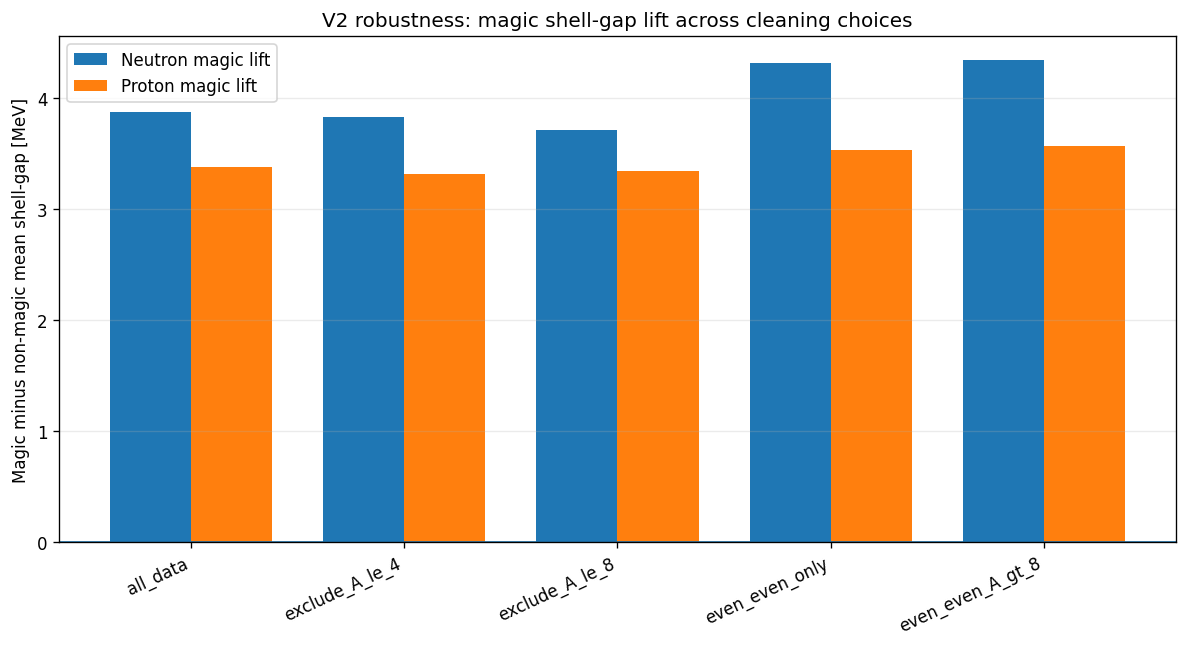

Saved: ecsm_magic_numbers_response_closure_v2_out/figures/fig01_v2_magic_lift_robustness.png


In [8]:
# CELL 07 — FIGURE 1: RAW VS CLEANED MAGIC LIFT

plot_df = robust_stats.copy()
plot_df["channel_label"] = plot_df["channel"].map({"N":"Neutron $\\delta_{2n}$", "Z":"Proton $\\delta_{2p}$"})

fig, ax = plt.subplots(figsize=(10, 5.5))
x = np.arange(len(plot_df["sample"].unique()))
samples = list(plot_df["sample"].unique())
width = 0.38
for i, ch in enumerate(["N", "Z"]):
    vals = [float(plot_df[(plot_df["sample"]==s)&(plot_df["channel"]==ch)]["mean_lift_MeV"].iloc[0]) for s in samples]
    ax.bar(x + (i-0.5)*width, vals, width, label=("Neutron magic lift" if ch=="N" else "Proton magic lift"))
ax.axhline(0, linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(samples, rotation=25, ha="right")
ax.set_ylabel("Magic minus non-magic mean shell-gap [MeV]")
ax.set_title("V2 robustness: magic shell-gap lift across cleaning choices")
ax.grid(True, axis="y", alpha=0.25)
ax.legend()
fig.tight_layout()
fig.savefig(FIG / "fig01_v2_magic_lift_robustness.png", dpi=300, bbox_inches="tight")
fig.savefig(FIG / "fig01_v2_magic_lift_robustness.pdf", bbox_inches="tight")
plt.show()
print("Saved:", FIG / "fig01_v2_magic_lift_robustness.png")

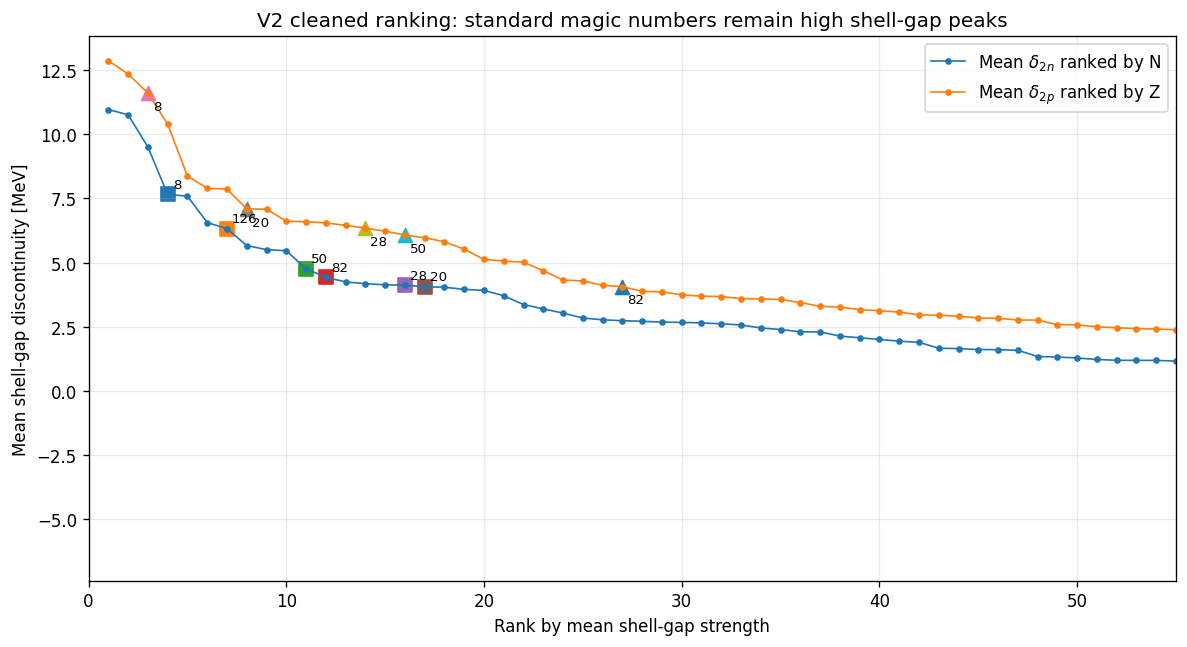

Saved: ecsm_magic_numbers_response_closure_v2_out/figures/fig02_v2_cleaned_ranked_shell_gaps.png


In [9]:
# CELL 08 — FIGURE 2: RANKED MEAN SHELL-GAP PROFILES AFTER A>8 CLEANING

clean = SAMPLES["exclude_A_le_8"]
n_prof = ranked_profile(clean, "N")
z_prof = ranked_profile(clean, "Z")

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(n_prof["rank"], n_prof["delta2n_MeV"], marker="o", markersize=3, linewidth=1, label="Mean $\\delta_{2n}$ ranked by N")
ax.plot(z_prof["rank"], z_prof["delta2p_MeV"], marker="o", markersize=3, linewidth=1, label="Mean $\\delta_{2p}$ ranked by Z")
for _, r in n_prof[n_prof["is_magic"]].iterrows():
    ax.scatter(r["rank"], r["delta2n_MeV"], s=70, marker="s")
    ax.annotate(str(int(r["N"])), (r["rank"], r["delta2n_MeV"]), textcoords="offset points", xytext=(3,4), fontsize=8)
for _, r in z_prof[z_prof["is_magic"]].iterrows():
    ax.scatter(r["rank"], r["delta2p_MeV"], s=70, marker="^")
    ax.annotate(str(int(r["Z"])), (r["rank"], r["delta2p_MeV"]), textcoords="offset points", xytext=(3,-10), fontsize=8)
ax.set_xlim(0, 55)
ax.set_xlabel("Rank by mean shell-gap strength")
ax.set_ylabel("Mean shell-gap discontinuity [MeV]")
ax.set_title("V2 cleaned ranking: standard magic numbers remain high shell-gap peaks")
ax.grid(True, alpha=0.25)
ax.legend()
fig.tight_layout()
fig.savefig(FIG / "fig02_v2_cleaned_ranked_shell_gaps.png", dpi=300, bbox_inches="tight")
fig.savefig(FIG / "fig02_v2_cleaned_ranked_shell_gaps.pdf", bbox_inches="tight")
plt.show()
print("Saved:", FIG / "fig02_v2_cleaned_ranked_shell_gaps.png")

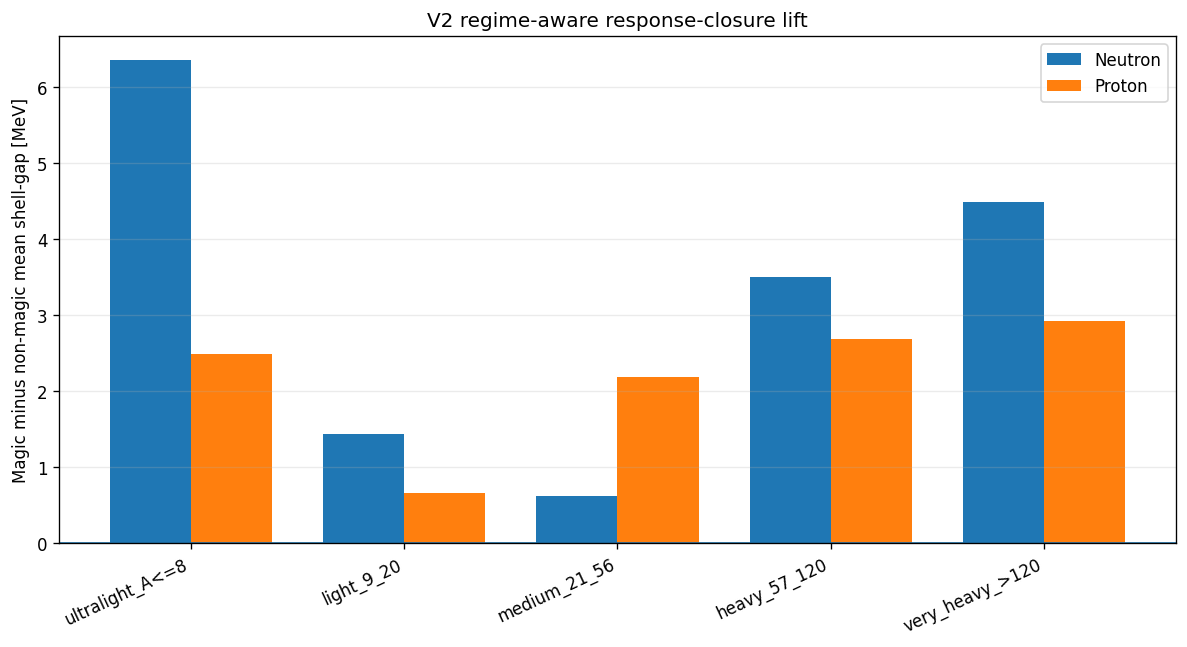

Saved: ecsm_magic_numbers_response_closure_v2_out/figures/fig03_v2_regime_aware_magic_lift.png


In [10]:
# CELL 09 — FIGURE 3: REGIME-AWARE MAGIC LIFT

reg_plot = regime_stats.copy()
fig, ax = plt.subplots(figsize=(10, 5.5))
regimes = list(reg_plot["A_regime"].unique())
x = np.arange(len(regimes))
width = 0.38
for i, ch in enumerate(["N", "Z"]):
    vals=[]
    for rg in regimes:
        sub = reg_plot[(reg_plot["A_regime"]==rg)&(reg_plot["channel"]==ch)]
        vals.append(float(sub["mean_lift_MeV"].iloc[0]) if len(sub) else np.nan)
    ax.bar(x + (i-0.5)*width, vals, width, label=("Neutron" if ch=="N" else "Proton"))
ax.axhline(0, linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(regimes, rotation=25, ha="right")
ax.set_ylabel("Magic minus non-magic mean shell-gap [MeV]")
ax.set_title("V2 regime-aware response-closure lift")
ax.grid(True, axis="y", alpha=0.25)
ax.legend()
fig.tight_layout()
fig.savefig(FIG / "fig03_v2_regime_aware_magic_lift.png", dpi=300, bbox_inches="tight")
fig.savefig(FIG / "fig03_v2_regime_aware_magic_lift.pdf", bbox_inches="tight")
plt.show()
print("Saved:", FIG / "fig03_v2_regime_aware_magic_lift.png")

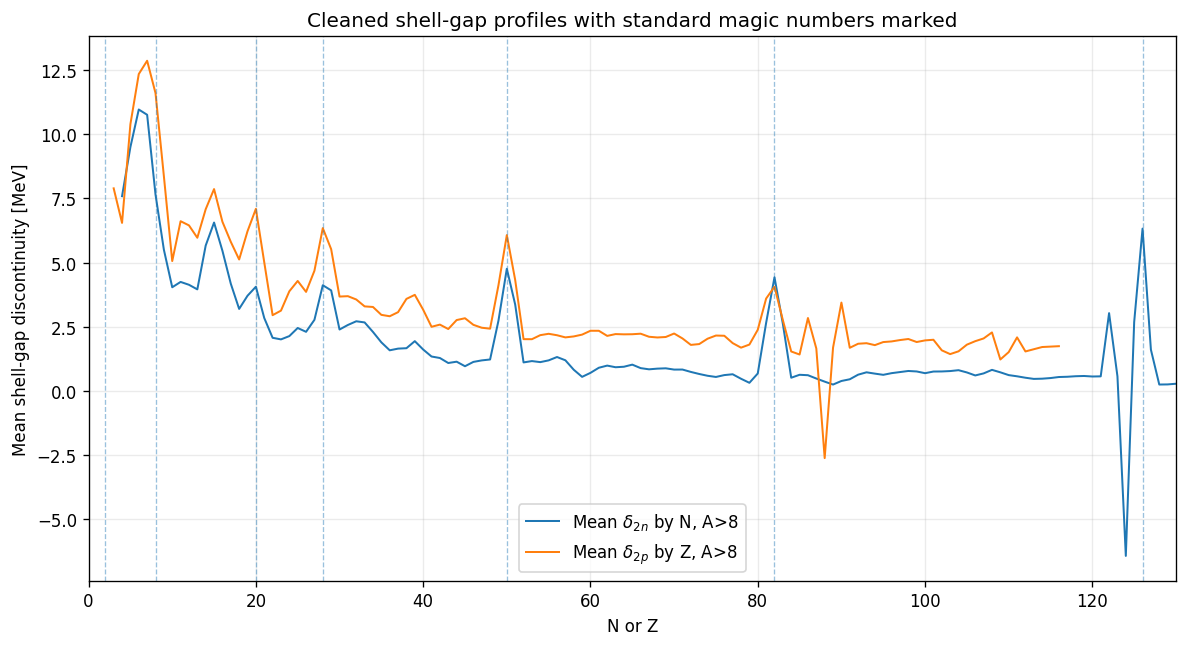

Saved: ecsm_magic_numbers_response_closure_v2_out/figures/fig04_v2_cleaned_shell_gap_profiles.png


In [11]:
# CELL 10 — FIGURE 4: CLEANED MEAN GAP PROFILES BY CLOSURE NUMBER

n_profile_clean = (clean[np.isfinite(clean["delta2n_MeV"])]
                   .groupby("N", as_index=False)["delta2n_MeV"].mean())
z_profile_clean = (clean[np.isfinite(clean["delta2p_MeV"])]
                   .groupby("Z", as_index=False)["delta2p_MeV"].mean())

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(n_profile_clean["N"], n_profile_clean["delta2n_MeV"], linewidth=1.2, label="Mean $\\delta_{2n}$ by N, A>8")
ax.plot(z_profile_clean["Z"], z_profile_clean["delta2p_MeV"], linewidth=1.2, label="Mean $\\delta_{2p}$ by Z, A>8")
for m in MAGIC:
    ax.axvline(m, linestyle="--", linewidth=0.8, alpha=0.45)
ax.set_xlim(0, 130)
ax.set_xlabel("N or Z")
ax.set_ylabel("Mean shell-gap discontinuity [MeV]")
ax.set_title("Cleaned shell-gap profiles with standard magic numbers marked")
ax.grid(True, alpha=0.25)
ax.legend()
fig.tight_layout()
fig.savefig(FIG / "fig04_v2_cleaned_shell_gap_profiles.png", dpi=300, bbox_inches="tight")
fig.savefig(FIG / "fig04_v2_cleaned_shell_gap_profiles.pdf", bbox_inches="tight")
plt.show()
print("Saved:", FIG / "fig04_v2_cleaned_shell_gap_profiles.png")

,magic_number,n_delta2n_rows,delta2n_mean_MeV,delta2n_median_MeV,n_delta2p_rows,delta2p_mean_MeV,delta2p_median_MeV
0,2,0,NaN,NaN,0,NaN,NaN
1,8,9,7.657156,6.675953,12,11.609364,12.060751
2,20,15,4.060157,4.158212,20,7.095309,7.296228
3,28,18,4.118452,4.553351,27,6.345035,6.176360
4,50,22,4.760932,4.987067,35,6.073305,5.528468
5,82,26,4.428989,4.148356,35,4.061541,3.685206
6,126,15,6.325116,3.476698,0,NaN,NaN


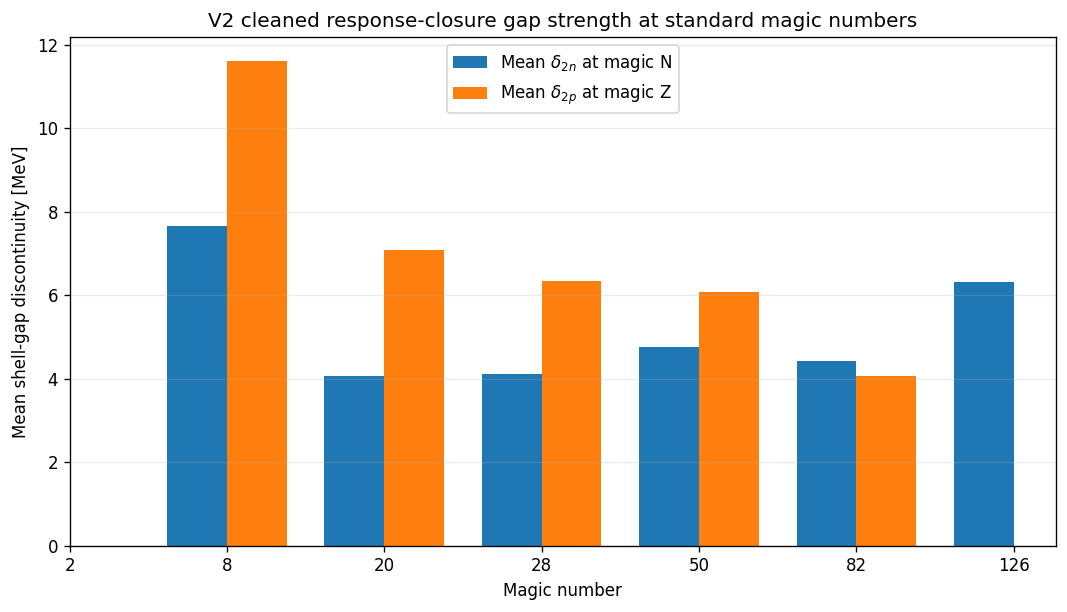

Saved: ecsm_magic_numbers_response_closure_v2_out/figures/fig05_v2_magic_number_gap_strength_cleaned.png


In [12]:
# CELL 11 — FIGURE 5: MAGIC NUMBER GAP STRENGTH BAR CHART, CLEANED A>8

magic_rows=[]
for m in MAGIC:
    n_sub = clean[(clean["N"]==m) & np.isfinite(clean["delta2n_MeV"])]
    z_sub = clean[(clean["Z"]==m) & np.isfinite(clean["delta2p_MeV"])] if m in MAGIC_Z else clean.iloc[0:0]
    magic_rows.append({
        "magic_number": int(m),
        "n_delta2n_rows": int(len(n_sub)),
        "delta2n_mean_MeV": float(n_sub["delta2n_MeV"].mean()) if len(n_sub) else np.nan,
        "delta2n_median_MeV": float(n_sub["delta2n_MeV"].median()) if len(n_sub) else np.nan,
        "n_delta2p_rows": int(len(z_sub)),
        "delta2p_mean_MeV": float(z_sub["delta2p_MeV"].mean()) if len(z_sub) else np.nan,
        "delta2p_median_MeV": float(z_sub["delta2p_MeV"].median()) if len(z_sub) else np.nan,
    })
magic_clean_summary = pd.DataFrame(magic_rows)
magic_clean_summary.to_csv(TAB / "v2_cleaned_magic_number_gap_summary.csv", index=False)
display(magic_clean_summary)

fig, ax = plt.subplots(figsize=(9, 5.2))
x = np.arange(len(magic_clean_summary))
width=0.38
ax.bar(x-width/2, magic_clean_summary["delta2n_mean_MeV"], width, label="Mean $\\delta_{2n}$ at magic N")
ax.bar(x+width/2, magic_clean_summary["delta2p_mean_MeV"], width, label="Mean $\\delta_{2p}$ at magic Z")
ax.set_xticks(x)
ax.set_xticklabels(magic_clean_summary["magic_number"].astype(str))
ax.set_xlabel("Magic number")
ax.set_ylabel("Mean shell-gap discontinuity [MeV]")
ax.set_title("V2 cleaned response-closure gap strength at standard magic numbers")
ax.grid(True, axis="y", alpha=0.25)
ax.legend()
fig.tight_layout()
fig.savefig(FIG / "fig05_v2_magic_number_gap_strength_cleaned.png", dpi=300, bbox_inches="tight")
fig.savefig(FIG / "fig05_v2_magic_number_gap_strength_cleaned.pdf", bbox_inches="tight")
plt.show()
print("Saved:", FIG / "fig05_v2_magic_number_gap_strength_cleaned.png")

## V2 interpretation checkpoint

The key success criteria are deliberately conservative:

1. magic-number mean shell gaps exceed non-magic mean shell gaps in both neutron and proton channels;
2. median lifts are also positive, so the signal is not only due to a few outliers;
3. the cleaned A>8 ranking recovers most standard magic numbers in the top-ranked shell-gap profile;
4. regime analysis does not erase the signal, even if light-sector behaviour is stronger and noisier.

In [13]:
# CELL 12 — FINAL V2 VERDICT AND EXPORTS

# Key rows for final claims.
def row_lookup(df, sample, channel):
    return df[(df["sample"]==sample) & (df["channel"]==channel)].iloc[0].to_dict()

all_N = row_lookup(robust_stats, "all_data", "N")
all_Z = row_lookup(robust_stats, "all_data", "Z")
clean_N = row_lookup(robust_stats, "exclude_A_le_8", "N")
clean_Z = row_lookup(robust_stats, "exclude_A_le_8", "Z")

def top_magic_values(sample, channel, k):
    r = rank_summary[(rank_summary["sample"]==sample)&(rank_summary["channel"]==channel)&(rank_summary["top_k"]==k)]
    return r["magic_values"].iloc[0] if len(r) else ""

verdict = {
    "notebook": "ECSM_Magic_Numbers_Response_Closure_V2_Regime_Aware_Robustness",
    "data_source": str(AME_CSV),
    "n_nuclides_used": int(len(work)),
    "magic_numbers_tested_N": [int(x) for x in MAGIC_N],
    "magic_numbers_tested_Z": [int(x) for x in MAGIC_Z],
    "v1_like_all_data": {
        "neutron_mean_lift_MeV": float(all_N["mean_lift_MeV"]),
        "neutron_median_lift_MeV": float(all_N["median_lift_MeV"]),
        "proton_mean_lift_MeV": float(all_Z["mean_lift_MeV"]),
        "proton_median_lift_MeV": float(all_Z["median_lift_MeV"]),
    },
    "v2_clean_A_gt_8": {
        "neutron_mean_lift_MeV": float(clean_N["mean_lift_MeV"]),
        "neutron_median_lift_MeV": float(clean_N["median_lift_MeV"]),
        "proton_mean_lift_MeV": float(clean_Z["mean_lift_MeV"]),
        "proton_median_lift_MeV": float(clean_Z["median_lift_MeV"]),
        "N_top20_magic_values": top_magic_values("exclude_A_le_8", "N", 20),
        "Z_top30_magic_values": top_magic_values("exclude_A_le_8", "Z", 30),
    },
    "qualitative_pass_flags": {
        "all_data_N_mean_lift_positive": bool(all_N["mean_lift_MeV"] > 0),
        "all_data_Z_mean_lift_positive": bool(all_Z["mean_lift_MeV"] > 0),
        "clean_A_gt_8_N_mean_lift_positive": bool(clean_N["mean_lift_MeV"] > 0),
        "clean_A_gt_8_Z_mean_lift_positive": bool(clean_Z["mean_lift_MeV"] > 0),
        "clean_A_gt_8_N_median_lift_positive": bool(clean_N["median_lift_MeV"] > 0),
        "clean_A_gt_8_Z_median_lift_positive": bool(clean_Z["median_lift_MeV"] > 0),
    },
}

# ZIP figures and tables.
fig_zip = OUT / "ecsm_magic_numbers_v2_figures.zip"
tab_zip = OUT / "ecsm_magic_numbers_v2_tables.zip"
with zipfile.ZipFile(fig_zip, "w", zipfile.ZIP_DEFLATED) as z:
    for f in sorted(FIG.glob("*")):
        z.write(f, arcname=f.name)
with zipfile.ZipFile(tab_zip, "w", zipfile.ZIP_DEFLATED) as z:
    for f in sorted(TAB.glob("*")):
        z.write(f, arcname=f.name)

verdict["exports"] = {
    "figure_zip": str(fig_zip),
    "table_zip": str(tab_zip),
    "verdict_json": str(OUT / "magic_numbers_v2_verdict.json"),
}

with open(OUT / "magic_numbers_v2_verdict.json", "w") as f:
    json.dump(verdict, f, indent=2)

print("="*72)
print("ECSM MAGIC NUMBERS RESPONSE-CLOSURE V2 VERDICT")
print("="*72)
print(json.dumps(verdict, indent=2))
print("\nSaved:")
print(fig_zip)
print(tab_zip)
print(OUT / "magic_numbers_v2_verdict.json")

ECSM MAGIC NUMBERS RESPONSE-CLOSURE V2 VERDICT
{
  "notebook": "ECSM_Magic_Numbers_Response_Closure_V2_Regime_Aware_Robustness",
  "data_source": "/content/drive/MyDrive/ame2020.csv",
  "n_nuclides_used": 3378,
  "magic_numbers_tested_N": [
    2,
    8,
    20,
    28,
    50,
    82,
    126
  ],
  "magic_numbers_tested_Z": [
    2,
    8,
    20,
    28,
    50,
    82
  ],
  "v1_like_all_data": {
    "neutron_mean_lift_MeV": 3.871323007168767,
    "neutron_median_lift_MeV": 3.611165699999674,
    "proton_mean_lift_MeV": 3.379783065855442,
    "proton_median_lift_MeV": 3.388974299999944
  },
  "v2_clean_A_gt_8": {
    "neutron_mean_lift_MeV": 3.711892153029158,
    "neutron_median_lift_MeV": 3.6067798000008224,
    "proton_mean_lift_MeV": 3.34517284427529,
    "proton_median_lift_MeV": 3.3845914499999026,
    "N_top20_magic_values": "8,126,50,82,28,20",
    "Z_top30_magic_values": "8,20,28,50,82"
  },
  "qualitative_pass_flags": {
    "all_data_N_mean_lift_positive": true,
    "all_

## Paper-use summary

Use V1 as the raw-data evidence pass and V2 as the cleaned, regime-aware robustness pass. The recommended paper framing is:

> In the raw AME2020 shell-gap test, standard magic values show elevated two-particle separation-energy discontinuities relative to non-magic values. In V2, this signal survives removal of ultra-light nuclei and paired-subset checks, supporting the interpretation of magic numbers as response-closure minima or completed finite-response layers in the ECSM framework.

The paper should still be careful: this is not a full shell-model derivation. It is a quantitative shell-gap recovery test showing that known magic closures occupy enhanced response-discontinuity locations in AME2020 data.